# Creating an Reservoir Artificial Metabolic (AMN) Reservoir with **Aida & Ying (2025)** experimental medium


This notebook demonstrates the pipeline for using AMNs with a large-scale dataset of *Escherichia coli* growth under well-defined laboratory conditions (Aida & Ying, 2025). The purpose if to use this dataset for training Artificial Metabolic Networks (Faure et al., 2023) that can learn to map `media concentration` $\rightarrow$ `uptake flux`

---

Aida, H., & Ying, B. (2025). Population Dynamics of Escherichia coli Growing under Chemically Defined Media. Scientific Data, 12(1), 984. https://doi.org/10.1038/s41597-025-05356-3

## Set up environment

In [109]:
# Automatic module reloading
%load_ext autoreload
%autoreload 2

# Imports
import os
import sys

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Working directory
DIRECTORY = './'
print(os.listdir(DIRECTORY)) # prints the files


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
['.git', 'Duplicate_Model.ipynb', '.gitignore', 'Figures.ipynb', 'experiments', 'Build_Model_ANN_Dense.ipynb', 'Build_Dataset.ipynb', 'Figures', 'Result', 'Tutorial.ipynb', 'Build_Model_MM.ipynb', 'pyproject.toml', 'Reservoir', 'environment_amn.yml', 'Tutorial_Aida.ipynb', 'Build_Experimental.ipynb', 'Dataset_model', 'uv.lock', 'Build_Dataset_KO.ipynb', 'Build_Model_RC.ipynb', 'environment_amn_light.yml', 'Library', 'Tutorial_Cmed.ipynb', 'README.md', 'Build_Model_AMN.ipynb', 'Dataset_experimental', 'Build_Model_AMN_KO.ipynb', '.venv', 'LICENSE', 'Dataset_input']


In [110]:
# Check GPU availability

# Set the log level to suppress warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' # filter out INFO, WARNING, and ERROR logs

import tensorflow as tf
print(f"TensorFlow Version: {tf.__version__}")
print(f"GPUs: {len(tf.config.list_physical_devices('GPU'))}")

TensorFlow Version: 2.15.1
GPUs: 1


## Step 1: Prepare Genome-Scale Model

A requirement for neural computations with metabolic networks using AMNs is the positivity of all fluxes. This means duplicating the reversible reactions in the Genome-Scale Model (GEM) used, making it irreversible.

The following steps transform an SBML model into an *AMN-compatible*  model where: **all exchange reactions are possible in both ways, and reversible internal reactions are duplicated for each way**.

In [111]:
# Import the module
from Library.Duplicate_Model import *

In [112]:
# iML1515 model
model_path = "Dataset_input/iML1515.xml"
url = "http://bigg.ucsd.edu/static/models/iML1515.xml"
response = requests.get(url)
open(model_path, "wb").write(response.content)
model = cobra.io.read_sbml_model(model_path)

In [113]:
# Boundary reactions
# reactions that introduce or remove matter in the system (inflows, outflows)
boundary_rxns = model.boundary
print(f"Total number of boundary reactions: {len(boundary_rxns)}")
    
# Medium reactions
# reactions in .boundary that are reversible
medium_rxns = model.medium
print(f"\nTotal number of medium reactions: {len(medium_rxns)}")
print(f"All medium reactions: {medium_rxns}")


Total number of boundary reactions: 337

Total number of medium reactions: 24
All medium reactions: {'EX_pi_e': 1000.0, 'EX_co2_e': 1000.0, 'EX_fe3_e': 1000.0, 'EX_h_e': 1000.0, 'EX_mn2_e': 1000.0, 'EX_fe2_e': 1000.0, 'EX_glc__D_e': 10.0, 'EX_zn2_e': 1000.0, 'EX_mg2_e': 1000.0, 'EX_ca2_e': 1000.0, 'EX_ni2_e': 1000.0, 'EX_cu2_e': 1000.0, 'EX_sel_e': 1000.0, 'EX_cobalt2_e': 1000.0, 'EX_h2o_e': 1000.0, 'EX_mobd_e': 1000.0, 'EX_so4_e': 1000.0, 'EX_nh4_e': 1000.0, 'EX_k_e': 1000.0, 'EX_na1_e': 1000.0, 'EX_cl_e': 1000.0, 'EX_o2_e': 1000.0, 'EX_tungs_e': 1000.0, 'EX_slnt_e': 1000.0}


In [114]:
io_dict = {"_i": [(None, "e"), (None, "c"), ("e","p"), ("p", "c"), ("e", "c"), ("c", "m"), ("p", "m")],
           "_o": [("c", None), ("e", None), ("p", "e"), ("c", "p"), ("c", "e"), ("m", "c"), ("m", "p")]}

unsignificant_mols = ["h_p", "h_c", "pi_c", "pi_p", "adp_c", "h2o_c", "atp_c"]

# Dictionary counting the reactions in reversible, forward, backward, open 
reac_id_to_io_count_and_way = screen_out_in(model, io_dict, unsignificant_mols)

# Structure of the screening dictionary
print()
print(reac_id_to_io_count_and_way)

{'r': 663, 'f': 2047, 'b': 0, 'o': 2}

{'NDPK5': [{'_i': 0, '_o': 0}, 'r'], 'SHK3Dr': [{'_i': 0, '_o': 0}, 'r'], 'NDPK6': [{'_i': 0, '_o': 0}, 'r'], 'NDPK8': [{'_i': 0, '_o': 0}, 'r'], 'DHORTS': [{'_i': 0, '_o': 0}, 'r'], 'PYNP2r': [{'_i': 0, '_o': 0}, 'r'], 'ICDHyr': [{'_i': 0, '_o': 0}, 'r'], 'DURIPP': [{'_i': 0, '_o': 0}, 'r'], 'ACALD': [{'_i': 0, '_o': 0}, 'r'], 'MAN6PI': [{'_i': 0, '_o': 0}, 'r'], 'TRPAS2': [{'_i': 0, '_o': 0}, 'r'], 'ALAR': [{'_i': 0, '_o': 0}, 'r'], 'ALATA_L': [{'_i': 0, '_o': 0}, 'r'], 'PPM': [{'_i': 0, '_o': 0}, 'r'], 'ASPTA': [{'_i': 0, '_o': 0}, 'r'], 'EX_pi_e': [{'_i': 0, '_o': 1}, 'r'], 'EX_co2_e': [{'_i': 0, '_o': 1}, 'r'], 'A5PISO': [{'_i': 0, '_o': 0}, 'r'], 'EX_met__L_e': [{'_i': 0, '_o': 1}, 'f'], 'GTHOr': [{'_i': 0, '_o': 0}, 'r'], 'ILETA': [{'_i': 0, '_o': 0}, 'r'], 'EX_metsox_S__L_e': [{'_i': 0, '_o': 1}, 'f'], 'VALTA': [{'_i': 0, '_o': 0}, 'r'], 'IPPMIb': [{'_i': 0, '_o': 0}, 'r'], 'ORPT': [{'_i': 0, '_o': 0}, 'r'], 'PSCVT': [{'_i': 0, '_o': 0}, '

In [115]:
# Use the dictionary to generate the AMN-compatible model
new_model = duplicate_model(model, reac_id_to_io_count_and_way)

The default model had 2712 reactions and the duplicated-reactions model has 3682 reactions.


In [116]:
# all non-default medium exchange reactions with UB=0 are set to 1e-300
# so they still appear in the medium object.
default_med = model.medium
new_med = new_model.medium
correct_med =  correct_duplicated_med(default_med, new_med)
new_model.medium = correct_med

print(f"Default medium: {len(default_med)} compounds")
print(f"\nCorrected medium: {len(correct_med)} compounds")

Default medium: 24 compounds

Corrected medium: 331 compounds


In [117]:
# Rebuild indices and pointers in the model if necessary
new_model.repair() 

In [118]:
print("Original model's location: " + model_path)
new_name = model_path[:-4] + "_duplicated" + model_path[-4:]

cobra.io.write_sbml_model(new_model, new_name)
print("Duplicated model's location: " + new_name)

Original model's location: Dataset_input/iML1515.xml
Duplicated model's location: Dataset_input/iML1515_duplicated.xml


## Step 2. Aida & Ying Dataset Pre-processing
#### 2.1. Match the Aida & Ying Compounds to iML1515 reactions

In [119]:
# TO DO: Add the aida script process

# Here, use medium_rxns to filter the aida dataset (so we use the vars in the notebook)

#### 2.2. Generate parameter file for `FBA-simulated` training set

An `FBA-simulated` dataset will be generated for training the AMN Reservoir. The reservoir learns the stoichiometric and bound constraints of the GEM from diverse FBA solutions. Thus, the training dataset should:

1. Cover diverse flux patterns - coming from different carbon sources
2. All produce growth > 0 - no infeasible conditions

#### Parameters for random generation

A file with parameters for random generation for the `FBA-simulated` dataset is needed. It's a csv specifying:

- `level`: Number of discrete levels each medium flux can take.
    - `level` <= 1: Minimum medium (always on at a fixed value).
    - `level` > 1: Variable medium (can be turned on/off with multiple levels).

- `max_level`: Maximum value each medium flux can take. Used to compute the actual flux value when a variable medium is turned on.

- `ratio_drawing`: Ratio/probability of variable medium fluxes being turned on during random generation. Not used when `max_level` is provided

We will be using the parameter file from Faure et. al (2023). 

In [ ]:
# Load Aida & Yin dataset (already processed to match model's reactions)
aida_path = DIRECTORY + 'Dataset_input/aidaying_media_growth_amns.csv'
aida_df = pd.read_csv(aida_path)

# Compounds in the Aida & Ying dataset
print(f"Aida & Ying DataFrame shape: {aida_df.shape}")
print(f"Columns: {aida_df.columns.tolist()}")

Aida & Ying DataFrame shape: (924, 38)
Columns: ['EX_glc__D_e_i', 'EX_ala__L_e_i', 'EX_arg__L_e_i', 'EX_asn__L_e_i', 'EX_asp__L_e_i', 'EX_glu__L_e_i', 'EX_gln__L_e_i', 'EX_gly_e_i', 'EX_his__L_e_i', 'EX_ile__L_e_i', 'EX_leu__L_e_i', 'EX_lys__L_e_i', 'EX_met__L_e_i', 'EX_phe__L_e_i', 'EX_pro__L_e_i', 'EX_ser__L_e_i', 'EX_thr__L_e_i', 'EX_trp__L_e_i', 'EX_tyr__L_e_i', 'EX_val__L_e_i', 'EX_thm_e_i', 'EX_pydxn_e_i', 'EX_cys__L_e_i', 'EX_cl_e_i', 'EX_nh4_e_i', 'EX_so4_e_i', 'EX_pi_e_i', 'EX_k_e_i', 'EX_na1_e_i', 'EX_mg2_e_i', 'EX_ca2_e_i', 'EX_fe2_e_i', 'EX_zn2_e_i', 'EX_cu2_e_i', 'EX_mobd_e_i', 'EX_cit_e_i', 'EX_tsul_e_i', 'GR_AVG']


In [121]:
# EDA on aida_df
global_min = aida_df.min().min()
global_max = aida_df.max().max()
print(f"Minimum across all columns: {global_min}")
print(f"Maximum across all columns: {global_max}")


Minimum across all columns: 0.0
Maximum across all columns: 343.0


In [122]:
# Load parameter file from Faure et. al 
faure_path = DIRECTORY + 'Dataset_input/iML1515.csv'
faure_df = pd.read_csv(faure_path)

# Compounds in the Faure et. al parameter file
print(f"Faure DataFrame shape: {faure_df.shape}")
print(f"Columns: {faure_df.columns.tolist()}")
faure_df.head(3)

Faure DataFrame shape: (4, 39)
Columns: ['name', 'EX_pi_e_i', 'EX_co2_e_i', 'EX_fe3_e_i', 'EX_h_e_i', 'EX_mn2_e_i', 'EX_fe2_e_i', 'EX_zn2_e_i', 'EX_mg2_e_i', 'EX_ca2_e_i', 'EX_ni2_e_i', 'EX_cu2_e_i', 'EX_sel_e_i', 'EX_cobalt2_e_i', 'EX_h2o_e_i', 'EX_mobd_e_i', 'EX_so4_e_i', 'EX_nh4_e_i', 'EX_k_e_i', 'EX_na1_e_i', 'EX_cl_e_i', 'EX_o2_e_i', 'EX_tungs_e_i', 'EX_slnt_e_i', 'EX_glyc_e_i', 'EX_ala__L_e_i', 'EX_pro__L_e_i', 'EX_thr__L_e_i', 'EX_gly_e_i', 'EX_rib__D_e_i', 'EX_malt_e_i', 'EX_melib_e_i', 'EX_tre_e_i', 'EX_fru_e_i', 'EX_gal_e_i', 'EX_ac_e_i', 'EX_lac__D_e_i', 'EX_succ_e_i', 'EX_pyr_e_i']


,name,EX_pi_e_i,EX_co2_e_i,EX_fe3_e_i,EX_h_e_i,EX_mn2_e_i,EX_fe2_e_i,EX_zn2_e_i,EX_mg2_e_i,EX_ca2_e_i,...,EX_rib__D_e_i,EX_malt_e_i,EX_melib_e_i,EX_tre_e_i,EX_fru_e_i,EX_gal_e_i,EX_ac_e_i,EX_lac__D_e_i,EX_succ_e_i,EX_pyr_e_i
0,level,1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
1,max_value,2.2,2.2,2.2,2.2,2.2,2.2,2.2,2.2,2.2,...,2.2,2.2,2.2,2.2,2.2,2.2,2.2,2.2,2.2,2.2
2,ratio_drawing,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [123]:
# Store column names (excluding non-compounds)
faure_cols = faure_df.columns.drop('name')
aida_cols = aida_df.columns.drop('GR_AVG')

print(f"Faure compounds: {len(faure_cols)}")
print(f"Aida & Ying compounds: {len(aida_cols)}")

Faure compounds: 38
Aida & Ying compounds: 37


In [124]:
# Check common compounds
common_compounds = set(faure_cols) & set(aida_cols)
print(f"Common compounds: {len(common_compounds)}")
print(f"Common compounds: {common_compounds}")

# Check Aida only
aida_only = set(aida_cols) - set(faure_cols)
print(f"\nAida & Ying only compounds: {len(aida_only)}")
print(f"Aida & Ying only compounds: {aida_only}")

# Check Faure only
faure_only = set(faure_cols) - set(aida_cols)
print(f"\nFaure only compounds: {len(faure_only)}")
print(f"Faure only compounds: {faure_only}")

Common compounds: 16
Common compounds: {'EX_thr__L_e_i', 'EX_mobd_e_i', 'EX_gly_e_i', 'EX_so4_e_i', 'EX_ala__L_e_i', 'EX_ca2_e_i', 'EX_cu2_e_i', 'EX_nh4_e_i', 'EX_mg2_e_i', 'EX_na1_e_i', 'EX_k_e_i', 'EX_pi_e_i', 'EX_fe2_e_i', 'EX_zn2_e_i', 'EX_pro__L_e_i', 'EX_cl_e_i'}

Aida & Ying only compounds: 21
Aida & Ying only compounds: {'EX_thm_e_i', 'EX_cit_e_i', 'EX_gln__L_e_i', 'EX_ser__L_e_i', 'EX_glu__L_e_i', 'EX_trp__L_e_i', 'EX_val__L_e_i', 'EX_met__L_e_i', 'EX_tsul_e_i', 'EX_phe__L_e_i', 'EX_pydxn_e_i', 'EX_arg__L_e_i', 'EX_glc__D_e_i', 'EX_cys__L_e_i', 'EX_lys__L_e_i', 'EX_asp__L_e_i', 'EX_asn__L_e_i', 'EX_tyr__L_e_i', 'EX_his__L_e_i', 'EX_ile__L_e_i', 'EX_leu__L_e_i'}

Faure only compounds: 22
Faure only compounds: {'EX_lac__D_e_i', 'EX_fe3_e_i', 'EX_glyc_e_i', 'EX_o2_e_i', 'EX_mn2_e_i', 'EX_h_e_i', 'EX_rib__D_e_i', 'EX_ac_e_i', 'EX_succ_e_i', 'EX_tungs_e_i', 'EX_malt_e_i', 'EX_fru_e_i', 'EX_slnt_e_i', 'EX_co2_e_i', 'EX_tre_e_i', 'EX_sel_e_i', 'EX_cobalt2_e_i', 'EX_melib_e_i', 'EX_ni

We need to supplement the Faure parameter file with the compounds from the Aida & Ying dataset. This way, the reservoir will have seen flux patterns involving the experimental compounds.

We can classify the Aida & Ying only compounds in two categories:
- 2 Variable carbon sources: `EX_glc__D_e_i` and `EX_cit_e_i`
   - These can be ON/OFF
   - Assign `level`: 100, `max_value`: 2.2
- 19 Vitamins and aminoacids: `EX_thm_e_i`, `EX_arg__L_e_i`, ...
   - These are essential for growth and should always be ON
   - Assign `level`: 1, `max_value`: 2.2

The `max_value`: 2.2 is set to match Faure's original parameter file. Since the reservoir just needs to learn diverse feasible FBA patterns (not exact concentrations), keeping this arbitrary max values is valid.

In [125]:
# Add the Aida & Ying compounds to the Faure dataset

new_data = {}

for compound in aida_only:
    if compound in ['EX_glc__D_e_i', 'EX_cit_e_i']:
        level_val = 100
    else:
        level_val = 1
    # [name, level, max_value, ratio_drawing]
    new_data[compound] = [level_val, 0.5, np.nan, np.nan]


print(f"Original Faure shape: {faure_df.shape}")

# Add the new columns to the Faure dataset
if new_data:
    new_cols_df = pd.DataFrame(new_data, index=faure_df.index)
    faure_df = pd.concat([faure_df, new_cols_df], axis=1)

print(f"Faure shape with Aida & Ying compounds: {faure_df.shape}")
faure_df.head(3)

Original Faure shape: (4, 39)
Faure shape with Aida & Ying compounds: (4, 60)


,name,EX_pi_e_i,EX_co2_e_i,EX_fe3_e_i,EX_h_e_i,EX_mn2_e_i,EX_fe2_e_i,EX_zn2_e_i,EX_mg2_e_i,EX_ca2_e_i,...,EX_arg__L_e_i,EX_glc__D_e_i,EX_cys__L_e_i,EX_lys__L_e_i,EX_asp__L_e_i,EX_asn__L_e_i,EX_tyr__L_e_i,EX_his__L_e_i,EX_ile__L_e_i,EX_leu__L_e_i
0,level,1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,100.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1,max_value,2.2,2.2,2.2,2.2,2.2,2.2,2.2,2.2,2.2,...,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5
2,ratio_drawing,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Export
faure_df.to_csv(DIRECTORY + 'Dataset_input/aidaying_parameters.csv', index=False)

#### 2.3. Padding the Aida & Ying dataset

Because the AMN reservoir training data must match the experimental data (have the same type and number of `compounds`), the Aida & Ying dataset must be padded with the compounds in the Faure dataset. 

There's 2 categories of compounds in this padding:
- **Compounds present but not measured**
   - Reflect environmental conditions (`EX_o2_e_i`, `EX_co2_e_i`, ...)
   - These will be constant across all rows
   - Values (in mM) were selected from standard *E. coli* defined media concentrations
      - These could be adjusted
 - **Compounds genuinely absent**     
   - Not essential/environmental (`EX_glyc_e_i`, `EX_malt_e_i`, ...)
   - These will be 0 across all rows


*Note on H₂O:*
- A common value for water concentration in media is 55,000 mM, but this will be is an outlier that could dominate the feature space
- To prevent distorting the input distribution, we assign 500 for H₂O

In [127]:
# Compounds present but not measured
unmeasured_compounds = {
    'EX_o2_e_i': 0.21,
    'EX_co2_e_i': 0.013,
    'EX_h_e_i': 0.0001,
    'EX_h2o_e_i': 500.0,
    'EX_fe3_e_i': 0.0005,
    'EX_mn2_e_i': 0.0001,
    'EX_ni2_e_i': 0.0001,
    'EX_sel_e_i': 0.0001,
    'EX_cobalt2_e_i': 0.0001,
    'EX_tungs_e_i': 0.0001,
    'EX_slnt_e_i': 0.0001
}

# Compounds genuinely absent
absent_compounds = {
    'EX_glyc_e_i': 0.0,
    'EX_rib__D_e_i': 0.0,
    'EX_malt_e_i': 0.0,
    'EX_melib_e_i': 0.0,
    'EX_tre_e_i': 0.0,
    'EX_fru_e_i': 0.0,
    'EX_gal_e_i': 0.0,
    'EX_ac_e_i': 0.0,
    'EX_lac__D_e_i': 0.0,
    'EX_succ_e_i': 0.0,
    'EX_pyr_e_i': 0.0
}

compounds_to_add = {**unmeasured_compounds, **absent_compounds}

In [128]:
# Pad the Aida & Ying dataset with the missing compounds from the Faure dataset

print(f"Original Aida shape: {aida_df.shape}")

# Temporarily remove GR_AVG to preserve order
gr_avg_col = aida_df.pop('GR_AVG')

# Create a DataFrame with the new columns
new_data = {
    col: val 
    for col, val in compounds_to_add.items()
}
new_cols_df = pd.DataFrame(new_data, index=aida_df.index)

# Concatenate
aida_df = pd.concat([aida_df, new_cols_df], axis=1)

# Add GR_AVG back as last column
aida_df['GR_AVG'] = gr_avg_col

print(f"New Aida shape: {aida_df.shape}")

Original Aida shape: (924, 38)
New Aida shape: (924, 60)


In [ ]:
# Export
aida_df.to_csv(DIRECTORY + 'Dataset_input/aidaying_media_growth_amns_padded.csv', index=False)

## Step 3. Generate `FBA-simulated` training set for Reservoir AMN

An `FBA-simulated` dataset will be generated for the AMN Reservoir with experimental data.
This generation relies on using the Aida & Ying Dataset, a csv where `rows = conditions` and `cols = exchanges`+`growth_value`.

We use the padded version from the previous step.

### 3.1 Retrieve compounds in Aida & Ying padded

In [ ]:
from Library.Build_Dataset import *

# Set parameters
seed = 10
np.random.seed(seed=seed)  # seed for random number generator
cobraname =  'iML1515_duplicated' # name of the model 
mediumbound = 'UB' # Exact bound (EB) or upper bound (UB)
expname = 'aidaying_media_growth_amns_padded' # name of the experimental dataset for constraints
size, size_i  = 924, 50 # (# of exp conditions, training set size per condition)
reduce = False # Set at True if you want to reduce the model
mediumsize = 59 # number of medium compounds
verbose = True # prints

# Get X from experimental dataset
cobrafile = DIRECTORY+'Dataset_input/'+cobraname # .xml
expfile  = DIRECTORY+'Dataset_input/'+expname # .csv

# Generate a parameter object with the experimental data
parameter = TrainingSet(cobraname=cobrafile, 
                        mediumname=expfile, 
                        mediumbound=mediumbound, 
                        mediumsize=mediumsize, 
                        method='EXP',
                        verbose=verbose)


medium: ['EX_glc__D_e_i', 'EX_ala__L_e_i', 'EX_arg__L_e_i', 'EX_asn__L_e_i', 'EX_asp__L_e_i', 'EX_glu__L_e_i', 'EX_gln__L_e_i', 'EX_gly_e_i', 'EX_his__L_e_i', 'EX_ile__L_e_i', 'EX_leu__L_e_i', 'EX_lys__L_e_i', 'EX_met__L_e_i', 'EX_phe__L_e_i', 'EX_pro__L_e_i', 'EX_ser__L_e_i', 'EX_thr__L_e_i', 'EX_trp__L_e_i', 'EX_tyr__L_e_i', 'EX_val__L_e_i', 'EX_thm_e_i', 'EX_pydxn_e_i', 'EX_cys__L_e_i', 'EX_cl_e_i', 'EX_nh4_e_i', 'EX_so4_e_i', 'EX_pi_e_i', 'EX_k_e_i', 'EX_na1_e_i', 'EX_mg2_e_i', 'EX_ca2_e_i', 'EX_fe2_e_i', 'EX_zn2_e_i', 'EX_cu2_e_i', 'EX_mobd_e_i', 'EX_cit_e_i', 'EX_tsul_e_i', 'EX_o2_e_i', 'EX_co2_e_i', 'EX_h_e_i', 'EX_h2o_e_i', 'EX_fe3_e_i', 'EX_mn2_e_i', 'EX_ni2_e_i', 'EX_sel_e_i', 'EX_cobalt2_e_i', 'EX_tungs_e_i', 'EX_slnt_e_i', 'EX_glyc_e_i', 'EX_rib__D_e_i', 'EX_malt_e_i', 'EX_melib_e_i', 'EX_tre_e_i', 'EX_fru_e_i', 'EX_gal_e_i', 'EX_ac_e_i', 'EX_lac__D_e_i', 'EX_succ_e_i', 'EX_pyr_e_i']
levmed: []
valmed: []
ratmed: 0
objective:  ['BIOMASS_Ec_iML1515_core_75p37M']
measurements

In [131]:
# Store the medium data 
# (X matrix, where rows are conditions and columns are compounds)
X = parameter.X.copy()
print("X shape:")
print(X.shape)
print("X:")
print(f"{X}\n")

# Store the growth data 
# (Y vector, where each element is the growth rate of the condition)
Y = parameter.Y.copy()
print("Y shape:")
print(Y.shape)
print("Y:")
print(f"{Y}")

X shape:
(924, 59)
X:
[[2.000e+00 2.000e-02 2.000e-02 ... 0.000e+00 0.000e+00 0.000e+00]
 [2.000e+00 2.000e-02 2.000e-02 ... 0.000e+00 0.000e+00 0.000e+00]
 [2.000e+00 2.000e-02 2.000e-02 ... 0.000e+00 0.000e+00 0.000e+00]
 ...
 [4.342e+01 4.800e-01 4.600e-01 ... 0.000e+00 0.000e+00 0.000e+00]
 [4.342e+01 4.800e-01 4.600e-01 ... 0.000e+00 0.000e+00 0.000e+00]
 [4.342e+01 4.800e-01 4.600e-01 ... 0.000e+00 0.000e+00 0.000e+00]]

Y shape:
(924, 1)
Y:
[[0.        ]
 [1.35195701]
 [1.21247769]
 [1.31664145]
 [1.20613912]
 [1.2096604 ]
 [1.18665536]
 [1.2630026 ]
 [1.30251915]
 [1.16141401]
 [1.29121789]
 [1.19038438]
 [1.13983402]
 [0.93687068]
 [1.26857109]
 [1.05723604]
 [0.94498256]
 [1.1675341 ]
 [1.21453758]
 [1.15494106]
 [1.04952889]
 [1.22009679]
 [1.24604945]
 [1.16347754]
 [1.19674906]
 [1.23475186]
 [1.28648177]
 [1.22757426]
 [1.20015331]
 [1.15708897]
 [1.13678278]
 [1.15224194]
 [1.1473662 ]
 [1.07225977]
 [1.20539115]
 [1.12868891]
 [1.11913337]
 [1.06169291]
 [1.0134549 ]
 [

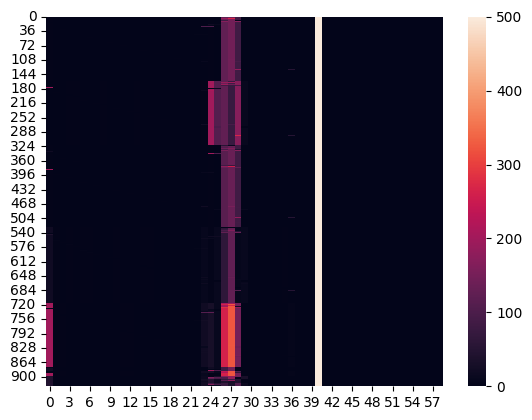

In [132]:
# Heatmap of the medium (conditions, compounds)
sns.heatmap(pd.DataFrame(X))
plt.show()

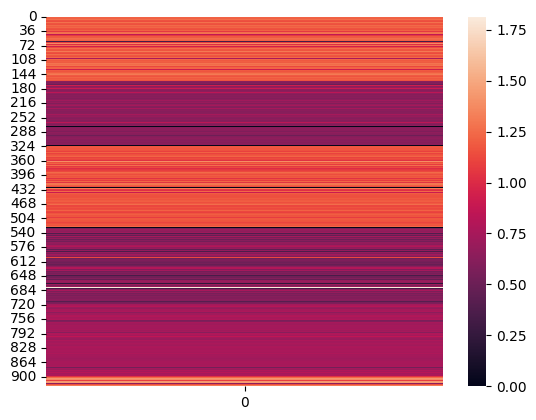

In [133]:
# Heatmap of the growth (conditions)
sns.heatmap(pd.DataFrame(Y))
plt.show()

In [ ]:
# Get parameter object for reservoir training set from a medium file
# 'method' is pFBA because this file contains parameters for random generation
mediumname = 'aidaying_parameters'
mediumfile = DIRECTORY+'Dataset_input/'+mediumname #.csv
parameter = TrainingSet(cobraname=cobrafile, 
                        mediumname=mediumfile, 
                        mediumbound=mediumbound, 
                        method='FBA',
                        verbose=verbose)

medium: ['EX_pi_e_i', 'EX_co2_e_i', 'EX_fe3_e_i', 'EX_h_e_i', 'EX_mn2_e_i', 'EX_fe2_e_i', 'EX_zn2_e_i', 'EX_mg2_e_i', 'EX_ca2_e_i', 'EX_ni2_e_i', 'EX_cu2_e_i', 'EX_sel_e_i', 'EX_cobalt2_e_i', 'EX_h2o_e_i', 'EX_mobd_e_i', 'EX_so4_e_i', 'EX_nh4_e_i', 'EX_k_e_i', 'EX_na1_e_i', 'EX_cl_e_i', 'EX_o2_e_i', 'EX_tungs_e_i', 'EX_slnt_e_i', 'EX_glyc_e_i', 'EX_ala__L_e_i', 'EX_pro__L_e_i', 'EX_thr__L_e_i', 'EX_gly_e_i', 'EX_rib__D_e_i', 'EX_malt_e_i', 'EX_melib_e_i', 'EX_tre_e_i', 'EX_fru_e_i', 'EX_gal_e_i', 'EX_ac_e_i', 'EX_lac__D_e_i', 'EX_succ_e_i', 'EX_pyr_e_i', 'EX_thm_e_i', 'EX_cit_e_i', 'EX_gln__L_e_i', 'EX_ser__L_e_i', 'EX_glu__L_e_i', 'EX_trp__L_e_i', 'EX_val__L_e_i', 'EX_met__L_e_i', 'EX_tsul_e_i', 'EX_phe__L_e_i', 'EX_pydxn_e_i', 'EX_arg__L_e_i', 'EX_glc__D_e_i', 'EX_cys__L_e_i', 'EX_lys__L_e_i', 'EX_asp__L_e_i', 'EX_asn__L_e_i', 'EX_tyr__L_e_i', 'EX_his__L_e_i', 'EX_ile__L_e_i', 'EX_leu__L_e_i']
levmed: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.

In [135]:
# Create varmed: the list of variable compound IDs, based on experimental file (X)
varmed = {}

for i in range(X.shape[0]):
    varmed[i] = []
    for j in range(X.shape[1]):
        if parameter.levmed[j] > 1 and X[i, j] > 0:
            varmed[i].append(parameter.medium[j])

varmed = list(varmed.values())

In [136]:
print(f"varmed len: {len(varmed)}")
print(varmed)

varmed len: 924
[['EX_rib__D_e_i', 'EX_malt_e_i', 'EX_melib_e_i', 'EX_tre_e_i', 'EX_fru_e_i', 'EX_gal_e_i', 'EX_ac_e_i', 'EX_lac__D_e_i', 'EX_succ_e_i', 'EX_pyr_e_i', 'EX_cit_e_i'], ['EX_rib__D_e_i', 'EX_malt_e_i', 'EX_melib_e_i', 'EX_tre_e_i', 'EX_fru_e_i', 'EX_gal_e_i', 'EX_ac_e_i', 'EX_lac__D_e_i', 'EX_succ_e_i', 'EX_pyr_e_i', 'EX_cit_e_i'], ['EX_rib__D_e_i', 'EX_malt_e_i', 'EX_melib_e_i', 'EX_tre_e_i', 'EX_fru_e_i', 'EX_gal_e_i', 'EX_ac_e_i', 'EX_lac__D_e_i', 'EX_succ_e_i', 'EX_pyr_e_i', 'EX_cit_e_i'], ['EX_rib__D_e_i', 'EX_malt_e_i', 'EX_melib_e_i', 'EX_tre_e_i', 'EX_fru_e_i', 'EX_gal_e_i', 'EX_ac_e_i', 'EX_lac__D_e_i', 'EX_succ_e_i', 'EX_pyr_e_i', 'EX_cit_e_i'], ['EX_rib__D_e_i', 'EX_malt_e_i', 'EX_melib_e_i', 'EX_tre_e_i', 'EX_fru_e_i', 'EX_gal_e_i', 'EX_ac_e_i', 'EX_lac__D_e_i', 'EX_succ_e_i', 'EX_pyr_e_i', 'EX_cit_e_i'], ['EX_rib__D_e_i', 'EX_malt_e_i', 'EX_melib_e_i', 'EX_tre_e_i', 'EX_fru_e_i', 'EX_gal_e_i', 'EX_ac_e_i', 'EX_lac__D_e_i', 'EX_succ_e_i', 'EX_pyr_e_i', 'EX_cit_

##### Explanation of `varmed`
`varmed` is a list that contains the compound IDs present per condition
- `varmed[0] = ['EX_gal_e_i']`: Condition 0 has only galactose as a variable medium
- `varmed[10] = ['EX_melib_e_i', 'EX_gal_e_i']`: Condition 10 has melibiose and galactose

If the compound exists in the medium (`if parameter.levmed[j] > 1`) and is present in the reference medium matrix (`and X[i,j] > 0`) it'll be appended to this list.

### 3.2. Creating the `FBA-simulated` dataset

For each condition (`varmed[i]`) generate `size_i` iterations of FBA-simulated data.

e.g. if `varmed[i] = 110` and `size_i = 100`, the `trainingsize = 11,000` (110x100)

In [137]:
size_i = 1 # samples to generate per condition

# Get a COBRApy-generated training set constrained by varmed
for i in range(X.shape[0]): 
    try:
        print(f"Condition {i}: {varmed[i]}")
        parameter.get(sample_size=size_i, varmed=varmed[i], verbose=True)
    except Exception as e:
        print(f"Skipping condition {i} (varmed={varmed[i]}): {e}")
        continue

Condition 0: ['EX_rib__D_e_i', 'EX_malt_e_i', 'EX_melib_e_i', 'EX_tre_e_i', 'EX_fru_e_i', 'EX_gal_e_i', 'EX_ac_e_i', 'EX_lac__D_e_i', 'EX_succ_e_i', 'EX_pyr_e_i', 'EX_cit_e_i']
sample: 0
pass (varmed, obj): ['EX_melib_e_i', 'EX_ac_e_i', 'EX_succ_e_i', 'EX_gal_e_i', 'EX_lac__D_e_i', 'EX_cit_e_i', 'EX_tre_e_i', 'EX_malt_e_i', 'EX_rib__D_e_i', 'EX_fru_e_i', 'EX_pyr_e_i'] 1.7803711215273366
primal objectif = ['BIOMASS_Ec_iML1515_core_75p37M'] FBA 1.7803711215274267
Condition 1: ['EX_rib__D_e_i', 'EX_malt_e_i', 'EX_melib_e_i', 'EX_tre_e_i', 'EX_fru_e_i', 'EX_gal_e_i', 'EX_ac_e_i', 'EX_lac__D_e_i', 'EX_succ_e_i', 'EX_pyr_e_i', 'EX_cit_e_i']
sample: 0
pass (varmed, obj): ['EX_rib__D_e_i', 'EX_pyr_e_i', 'EX_melib_e_i', 'EX_cit_e_i', 'EX_lac__D_e_i', 'EX_gal_e_i', 'EX_ac_e_i', 'EX_tre_e_i', 'EX_malt_e_i', 'EX_fru_e_i', 'EX_succ_e_i'] 1.9724211673100613
primal objectif = ['BIOMASS_Ec_iML1515_core_75p37M'] FBA 1.972421167309136
Condition 2: ['EX_rib__D_e_i', 'EX_malt_e_i', 'EX_melib_e_i', 'EX_tre

KeyboardInterrupt: 

In [ ]:
# Saving file
# trainingfile  = DIRECTORY+'Dataset_model/AidaYing_'+parameter.mediumbound
# parameter.save(trainingfile, reduce=reduce)

In [ ]:
# Verifying

from Library.Build_Dataset import *

trainingfile = DIRECTORY+'Dataset_model/iML1515_UB'
parameter = TrainingSet()
parameter.load(trainingfile)
print(trainingfile)
parameter.printout()

In [ ]:
# X training matrix (trainingsize, compounds)
X_fba_simulated = parameter.X.copy()
print("X shape (conditions, compounds):")
print(X_fba_simulated.shape)
print("X:")
print(f"{X_fba_simulated}\n")

# Y training matrix (trainingsize, flux values)
Y_fba_simulated = parameter.Y.copy()
print("Y shape (conditions, flux values):")
print(Y_fba_simulated.shape)
print("Y:")
print(f"{Y_fba_simulated}")

In [ ]:
# Heatmap of X (trainingsize, compounds)
sns.heatmap(pd.DataFrame(parameter.X))
plt.show()

In [ ]:
# Heatmap of Y (trainingsize, flux values)
sns.heatmap(pd.DataFrame(parameter.Y))
plt.show()

## Step 4. Build Artificial Metabolic Network (AMN)

This step aims to create a hybrid AMN model for learning on the COBRApy-generated dataset (see Step 2.2. above).

This will be used as the 'Reservoir Model' in the pipeline.

5-fold cross-validation is performed on 90% of the data and an independent test-set of 10% of the data.

\* Process from `Tutorial.ipynb` AMN cell

In [4]:
from Library.Build_Model import *

Using 1 GPU(s)


In [5]:
def printout(filename, Stats, model, time): 
    """
    Printout function for AMN models
    """
    # printing Stats
    print('Stats for %s GPU-time %.4f' % (filename, time))
    print('R2 = %.4f (+/- %.4f) Constraint = %.4f (+/- %.4f)' % \
          (Stats.train_objective[0], Stats.train_objective[1],
           Stats.train_loss[0], Stats.train_loss[1]))
    print('Q2 = %.4f (+/- %.4f) Constraint = %.4f (+/- %.4f)' % \
          (Stats.test_objective[0], Stats.test_objective[1],
           Stats.test_loss[0], Stats.test_loss[1]))

Create, train and evaluate AMN_QP model with FBA simulated training set for iML1515


In [ ]:
# Parameters
seed = 10
ratio_test = 0.1 # part of the training set removed for test
np.random.seed(seed=seed)  
trainname = 'iML1515_UB' # model, bounds
  
# Create model
trainingfile = DIRECTORY+'Dataset_model/'+trainname
model = Neural_Model(trainingfile = trainingfile, 
                     objective=['BIOMASS_Ec_iML1515_core_75p37M'],  
                     model_type='AMN_QP', 
                     timestep = 4, 
                     learn_rate=0.01,
                     scaler=True,
                     n_hidden = 1, 
                     hidden_dim = 50,
                     epochs=500,
                     xfold=5,
                     batch_size=128, # 5
                     es=True, # added early stopping
                     verbose=True)

# Split training and test set using ratio_test
ID = np.random.choice(model.X.shape[0], 
                      size=int(model.X.shape[0]*ratio_test), 
                      replace=False)
Xtest,  Ytest  = model.X[ID,:], model.Y[ID,:]
Xtrain, Ytrain = np.delete(model.X, ID, axis=0), np.delete(model.Y, ID, axis=0)
model.printout()

In [ ]:
# Train and evaluate (~35 mins)
reservoirname = trainname+'_'+model.model_type
reservoirfile = DIRECTORY+'Reservoir/'+reservoirname
start_time = time.time()
model.X, model.Y = Xtrain, Ytrain
reservoir, pred, stats, _ = train_evaluate_model(model, verbose=2)
delta_time = time.time() - start_time

In [ ]:
# Printing cross-validation results
printout(reservoirname, stats, model, delta_time)

In [ ]:
# Save, reload and run idependent test set (~10 mins)
reservoir.save(reservoirfile)
reservoir.load(reservoirfile)
reservoir.printout()
if len(Xtest) > 0:
    start_time = time.time()
    reservoir.X, reservoir.Y = Xtest, Ytest
    X, Y = model_input(reservoir, verbose=True)
    pred, stats = evaluate_model(reservoir.model, X, Y, reservoir, verbose=2)
    delta_time = time.time() - start_time
    printout('Test set', stats, model, delta_time)

## 4. Get predictions using experimental data + reservoir model

In [5]:
from Library.Build_Model import *

Using 1 GPU(s)


In [6]:
def printout(filename, Stats, model, time): 
    """
    Printout function for AMN models
    """
    # printing Stats
    print('Stats for %s GPU-time %.4f' % (filename, time))
    print('R2 = %.4f (+/- %.4f) Constraint = %.4f (+/- %.4f)' % \
          (Stats.train_objective[0], Stats.train_objective[1],
           Stats.train_loss[0], Stats.train_loss[1]))
    print('Q2 = %.4f (+/- %.4f) Constraint = %.4f (+/- %.4f)' % \
          (Stats.test_objective[0], Stats.test_objective[1],
           Stats.test_loss[0], Stats.test_loss[1]))

In [ ]:
# Create, train and evaluate reservoir models on experimental training set 
# Repeat the process with different seeds (~70 mins)

seed = 10
Maxloop, Q2, PRED = 3, [], []  
for Nloop in range(Maxloop):
    # Parameters
    seed = Nloop
    np.random.seed(seed=seed)  
    trainname = 'aidaying_media_growth_amns'
    reservoirname = 'iML1515_UB_AMN_QP'
  
    # Create model 
    trainingfile = DIRECTORY+'Dataset_input/'+trainname
    reservoirfile = DIRECTORY+'Reservoir/'+reservoirname
    X, Y = read_XY(trainingfile, 37)
    model = RC_Model(reservoirfile = reservoirfile, 
                     X=X, Y=Y, 
                     n_hidden_prior = 1, 
                     hidden_dim_prior = 500, 
                     activation_prior = 'relu',
                     epochs = 500, 
                     train_rate = 1.0e-3,
                     batch_size=128, # 5
                     xfold = 5,
                     es=False, # early stopping
                     verbose=True)
    model.printout()

    # Train and evaluate
    start_time = time.time()
    reservoir, pred, stats, _ = train_evaluate_model(model, verbose=2)
    delta_time = time.time() - start_time

    # Printing cross-validation results
    printout(reservoirname, stats, model, delta_time)
    r2 = r2_score(model.Y, pred[:,0], multioutput='variance_weighted')
    print('Iter', Nloop, 'Collated Q2', r2)
    Q2.append(r2)
    PRED.append(pred)

Instructions for updating:
Use `tf.linalg.matmul` instead
number of reactions:  3682 3682
number of metabolites:  1877
filtered measurements size:  1
RC reservoir file: ./Reservoir/iML1515_UB_AMN_QP
RC model type: RC
RC scaler: 0.0
RC model input dim: 37
RC model output dim: 1
RC model medium bound: UB
training set size (924, 37) (924, 1)
reservoir S, Pin, Pout matrices (1877, 3682) (38, 3682) (1, 3682)
RC training epochs: 500
RC training regression: True
RC training learn rate: 0.001
RC training dropout: 0.25
RC training batch size: 128
RC training validation iter: 0
RC training xfold: 5
RC training early stopping: False
--------prior network --------
training file: None
model type: ANN_Dense
model scaler: 0.0
model input dim: 9
model output dim: 9
model medium bound: 
timestep: 0
no training set provided
nbr hidden layer: 1
hidden layer size: 500
activation function: relu
--------reservoir network-----
training file: ./Dataset_model/iML1515_UB
model type: AMN_QP
model scaler: 11.0
mo

InvalidArgumentError: {{function_node __wrapped__MatMul_device_/job:localhost/replica:0/task:0/device:GPU:0}} Matrix size-incompatible: In[0]: [38,3682], In[1]: [37,1] [Op:MatMul] name: 

In [ ]:
# Some printings and savings
Q2, PRED = np.asarray(Q2), np.asarray(PRED)

print("")
print(PRED.shape)

obj = PRED[:,:,0]

print('Averaged Q2 = %.4f (+/- %.4f)' % (np.mean(Q2), np.std(Q2)))
filename = DIRECTORY+'Result/'+reservoirname+'_'\
+str(model.model_type)+'_Q2.csv'
np.savetxt(filename, Q2, delimiter=',')
filename = DIRECTORY+'Result/'+reservoirname+'_'\
+str(model.model_type)+'_PRED.csv'
np.savetxt(filename, obj, delimiter=',')

In [ ]:
# Saving input / output of the first prediction for Cobra runs
pred, obj = PRED[0], pred[:,0]
Loss_SV, Loss_Vin, Loss_Vpos = pred[:,1], pred[:,2], pred[:,3]
print('Loss SV average %.4f max %.4f' % (np.mean(Loss_SV), np.max(Loss_SV)))
print('Loss Vin average %.4f max %.4f' % (np.mean(Loss_Vin), np.max(Loss_Vin)))
print('Loss Vpos average %.4f max %.4f' % (np.mean(Loss_Vpos), np.max(Loss_Vpos)))

V = pred[:, 4:4+model.S.shape[1]]
Vin_pre_scaling = pred[:, 4+model.S.shape[1]:]
Vin = model.res.scaler * Vin_pre_scaling # rescale back for Cobra
XY = np.concatenate((Vin, Y), axis=1)
filename = DIRECTORY+'Result/'+reservoirname+'_'\
+str(model.model_type)+'_solution_for_Cobra.csv'
np.savetxt(filename, XY, delimiter=',')

## 5. Use RC predictions as input for COBRApy

The goal is to get a better growth rate estimate (comparing COBRApy predicted vs experimental value) when constraining the GEM with predicted medium fluxes.

\* Process from `Build_Dataset.ipynb` AMN cell

In [ ]:
# This cell run FBA on a provided training and compute R2 between
# provided objective and calculated objective
# For exprimental training set medium input fluxes can be scaled by a value

from Library.Build_Dataset import *
from sklearn.metrics import r2_score

# Parameters
seed = 10
np.random.seed(seed=seed)  
cobraname = 'iML1515_EXP'  # name of the model 
mediumbound = 'UB' # a must, exact bounds unknown
mediumname = 'iML1515_UB_AMN_QP_RC_solution_for_Cobra' # for running Cobra with RC predictions as inputs
#mediumname = 'iML1515_UB_AMN_QP_RC_AMN_solution_for_Cobra_pred' # for running Cobra with RC predictions as inputs
method = 'EXP' # FBA, pFBA or EXP

# Get data
cobrafile =  DIRECTORY+'Dataset_input/'+cobraname
mediumfile = DIRECTORY+'Dataset_input/'+mediumname
parameter = TrainingSet(cobraname=cobrafile, 
                        mediumname=mediumfile, 
                        mediumbound=mediumbound, 
                        mediumsize=38, 
                        method=method,
                        verbose=True)
scaler_list = [1] # best scaler for RC EXP input

# Regression cobra vs. true values
L = parameter.X.shape[0]
for scaler in scaler_list:
    Y = {}
    for i in range(L):
        inf = {r.id: 0 for r in parameter.model.reactions}
        for j in range(len(parameter.medium)):
            print(j, parameter.medium[j],parameter.X[i,j], len(parameter.model.reactions))
            eps = 1.0e-4 if parameter.X[i,j] < 1.0e-4 else 0
            inf[parameter.medium[j]] = scaler * parameter.X[i,j] + eps
        out,Y[i] = run_cobra(parameter.model, parameter.objective, inf, method='pFBA', verbose=False)
        print("%d %.4f %.4f" % (i, parameter.Y[i].item(), Y[i].item()))

    Y = list(Y.values())
    r2 = r2_score(parameter.Y[0:L], Y[0:L], multioutput='variance_weighted')
    print('scaler %.2f R2 %.4f ' % (scaler, r2))